In [1]:
#Read in libraries

In [171]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [108]:
#read in data

In [109]:
df = pd.read_csv("Student_Productivitiy.csv")
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [110]:
#explore basics

In [111]:
df.info() #need to change "gender" dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [112]:
df.describe() #no crazy skews other than final grade and focus score

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [113]:
df.shape

(20000, 18)

In [114]:
#Clean up data

In [115]:
df.isnull().sum()      #No nulls

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [116]:
df = df.drop(columns="student_id")

In [117]:
df.head()

,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [118]:
df.dtypes

age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

In [119]:
df.value_counts("gender")

gender
Female    9640
Male      9582
Other      778
Name: count, dtype: int64

In [120]:
df["gender"] = df["gender"].map({"Female":0,"Male":1,"Other":2})

In [121]:
#correlation testing 

In [122]:
correlation_matrix = df.corr()

<Axes: >

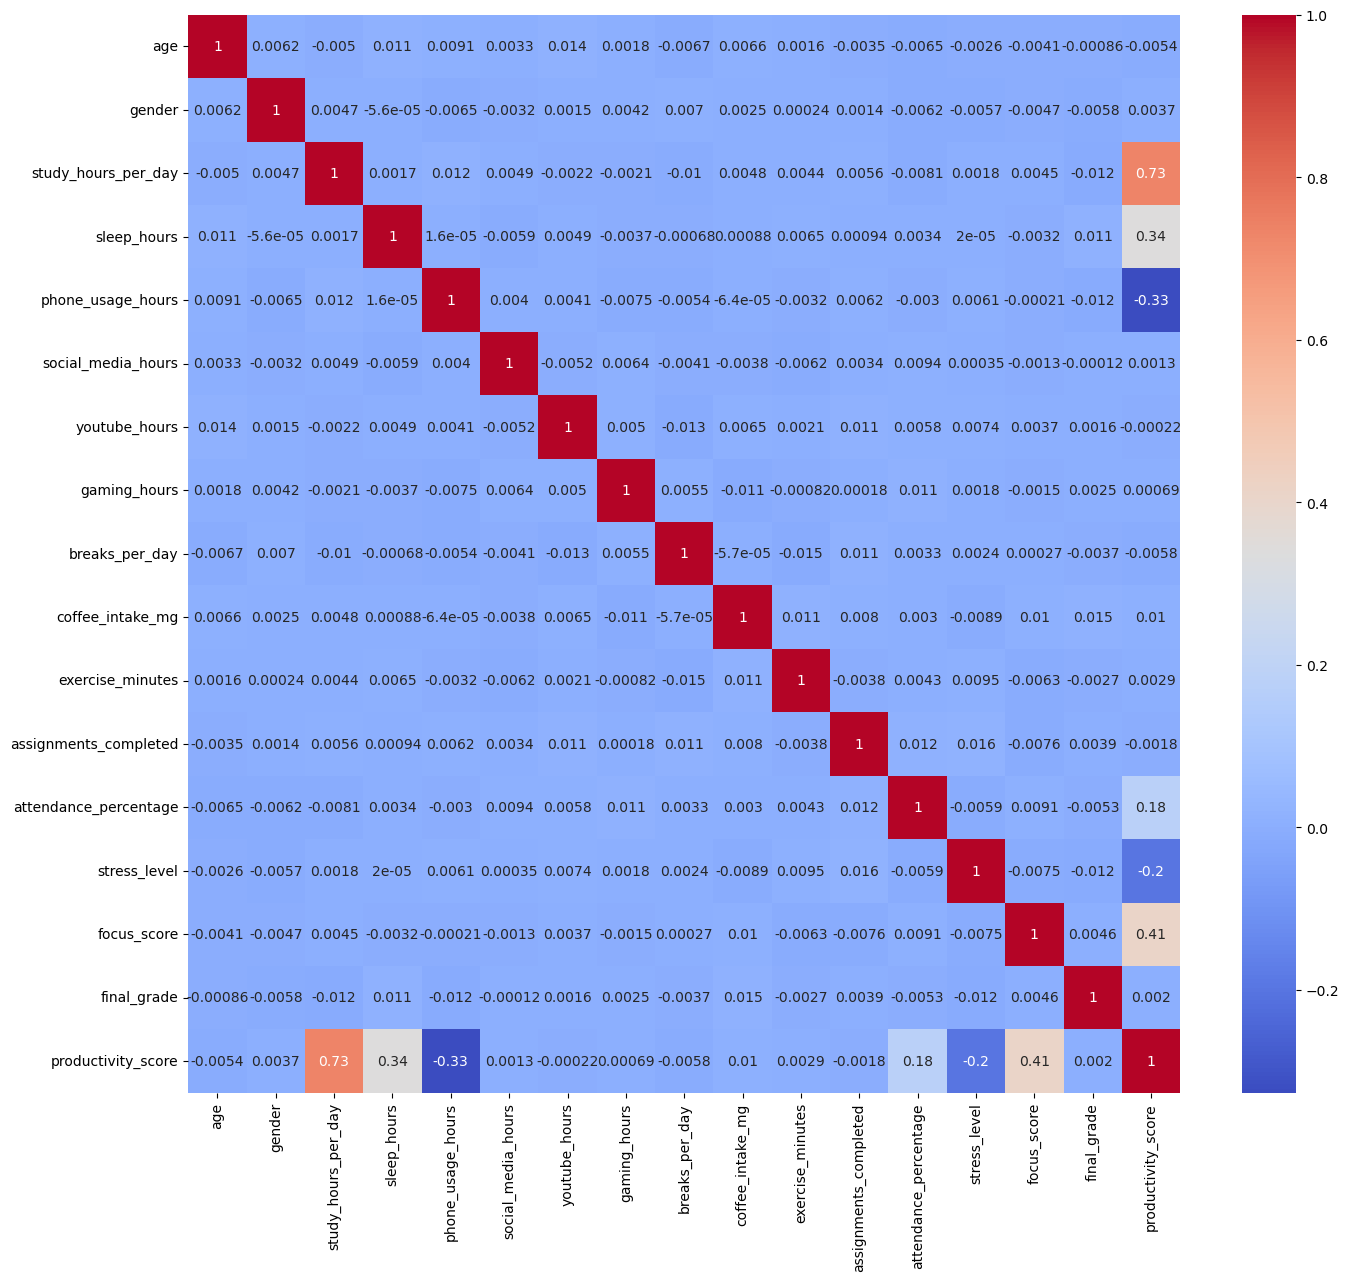

In [123]:
plt.figure(figsize=(16,14))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")

In [124]:
#significance testing 

In [125]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')

In [126]:
r, p_value = stats.pearsonr(df["age"],df["productivity_score"])
if p_value < .05:
    print(f"Significant relationship between age and productivity score (r={r}, p value={p_value})")
else:
    print("No Significant relationship between age and productivity score ")

No Significant relationship between age and productivity score 


In [127]:
r, p_value = stats.pearsonr(df["gender"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between gender and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between gender and productivity score")

No signficant relationship between gender and productivity score


In [128]:
r, p_value = stats.pearsonr(df["study_hours_per_day"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between study_hours_per_day and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between study_hours_per_day and productivity score")

Signficant relationship between study_hours_per_day and productivity_score (r=0.7327765360571934, p value=0.0)


In [129]:
r, p_value = stats.pearsonr(df["sleep_hours"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between sleep_hours and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between sleep_hours and productivity score")

Signficant relationship between sleep_hours and productivity_score (r=0.3409016321842879, p value=0.0)


In [130]:
r, p_value = stats.pearsonr(df["phone_usage_hours"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between phone_usage_hours and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between phone_usage_hours and productivity score")

Signficant relationship between phone_usage_hours and productivity_score (r=-0.32665040403164125, p value=0.0)


In [131]:
r, p_value = stats.pearsonr(df["social_media_hours"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between social_media_hours and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between social_media_hours and productivity score")

No signficant relationship between social_media_hours and productivity score


In [132]:
r, p_value = stats.pearsonr(df["youtube_hours"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between youtube_hours and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between youtube_hours and productivity score")

No signficant relationship between youtube_hours and productivity score


In [133]:
r, p_value = stats.pearsonr(df["gaming_hours"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between gaming_hours and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between gaming_hours and productivity score")

No signficant relationship between gaming_hours and productivity score


In [134]:
r, p_value = stats.pearsonr(df["breaks_per_day"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between breaks_per_day and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between breaks_per_day and productivity score")

No signficant relationship between breaks_per_day and productivity score


In [135]:
r, p_value = stats.pearsonr(df["coffee_intake_mg"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between coffee_intake_mg and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between coffee_intake_mg and productivity score")

No signficant relationship between coffee_intake_mg and productivity score


In [136]:
r, p_value = stats.pearsonr(df["exercise_minutes"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between exercise_minutes and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between exercise_minutes and productivity score")

No signficant relationship between exercise_minutes and productivity score


In [137]:
r, p_value = stats.pearsonr(df["assignments_completed"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between assignments_completed and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between assignments_completed and productivity score")

No signficant relationship between assignments_completed and productivity score


In [138]:
r, p_value = stats.pearsonr(df["attendance_percentage"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between attendance_percentage and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between attendance_percentage and productivity score")

Signficant relationship between attendance_percentage and productivity_score (r=0.17610714721442305, p value=4.953553288059658e-139)


In [139]:
r, p_value = stats.pearsonr(df["stress_level"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between stress_level and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between stress_level and productivity score")

Signficant relationship between stress_level and productivity_score (r=-0.19712750975408444, p value=2.2042213715760007e-174)


In [140]:
r, p_value = stats.pearsonr(df["focus_score"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between focus_score and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between focus_score and productivity score")

Signficant relationship between focus_score and productivity_score (r=0.41136614770598195, p value=0.0)


In [141]:
r, p_value = stats.pearsonr(df["final_grade"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between final_grade and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between final_grade and productivity score")

No signficant relationship between final_grade and productivity score


In [142]:
r, p_value = stats.pearsonr(df["final_grade"],df["productivity_score"])
if p_value < .05:
    print(f"Signficant relationship between final_grade and productivity_score (r={r}, p value={p_value})")
else:
    print("No signficant relationship between final_grade and productivity score")

No signficant relationship between final_grade and productivity score


In [143]:
#Significant values: study_hours_per_day, sleep_hours, phone_usage_hours, attendance_percentage, stress_level, focus_score

In [144]:
dfml = df[["study_hours_per_day","sleep_hours","phone_usage_hours","attendance_percentage","stress_level","focus_score","productivity_score"]]

In [145]:
dfml.head(1)

,study_hours_per_day,sleep_hours,phone_usage_hours,attendance_percentage,stress_level,focus_score,productivity_score
0,4.35,3.63,3.38,57.21,10,57,33.78


In [146]:
#Basic graphs

Text(0.5, 1.0, 'Distribution of Target Variable (Productivity Score)')

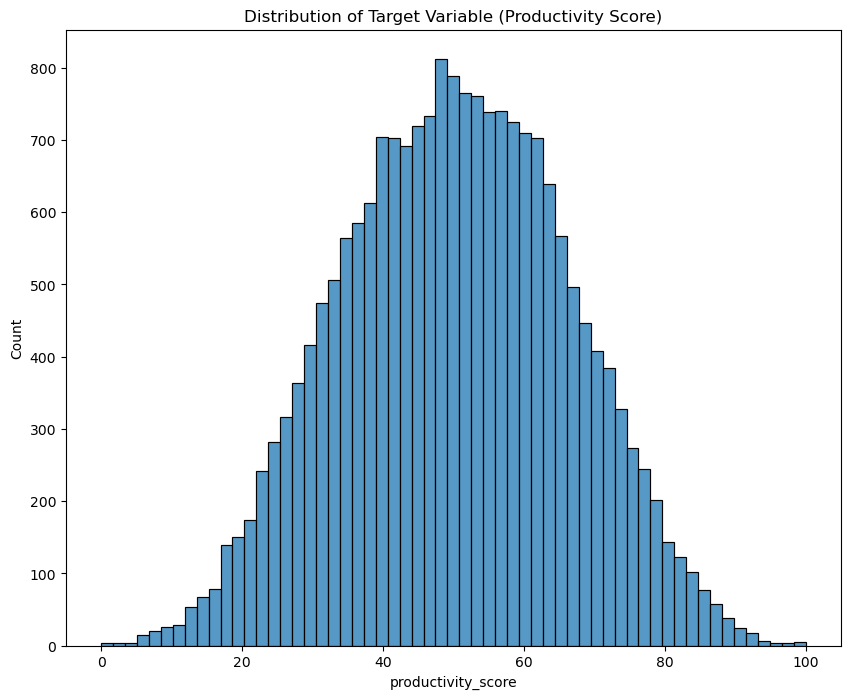

In [147]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x="productivity_score")
plt.title("Distribution of Target Variable (Productivity Score)")


<Axes: xlabel='productivity_score', ylabel='age'>

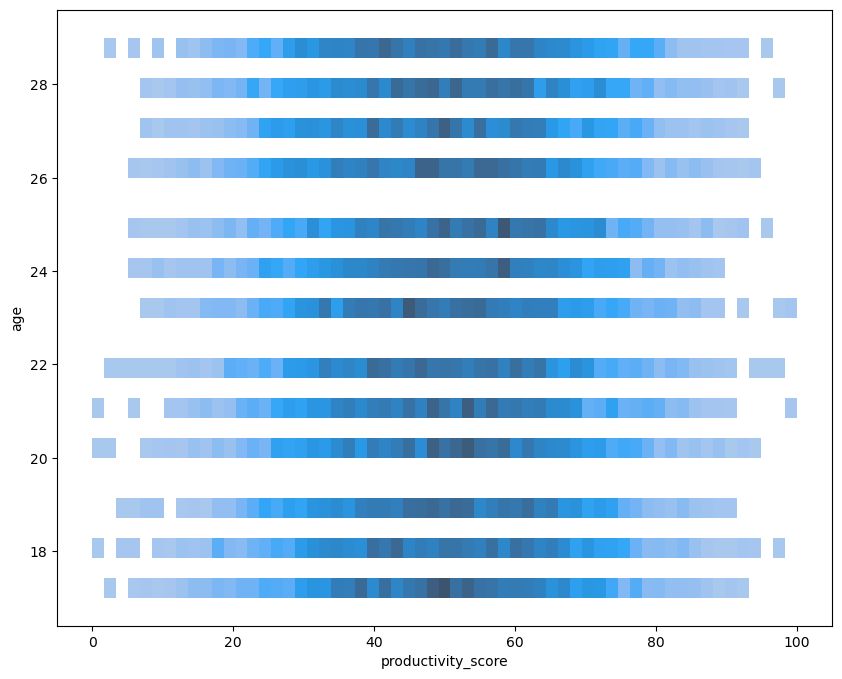

In [148]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x="productivity_score",y="age")

<Axes: xlabel='gender', ylabel='productivity_score'>

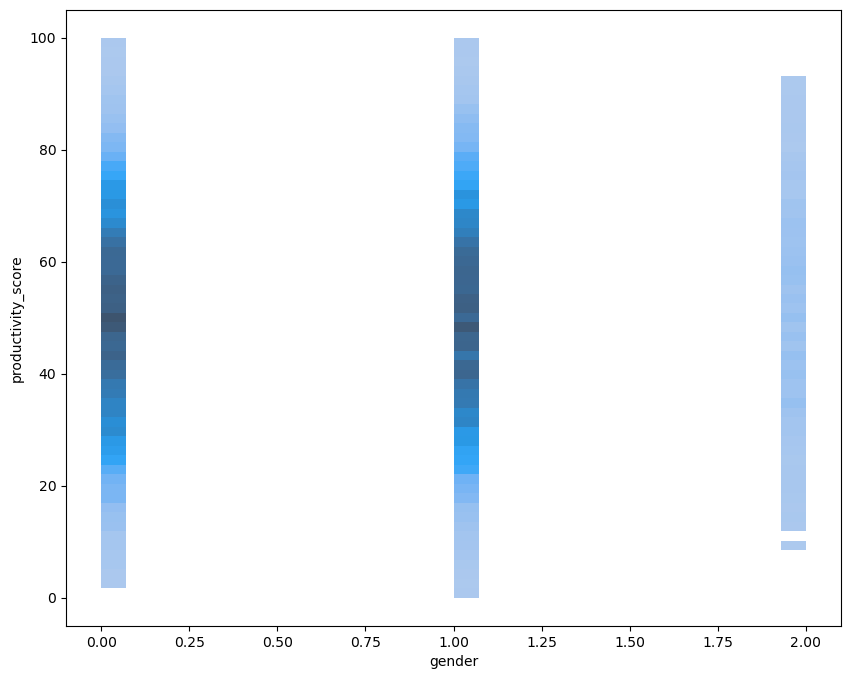

In [149]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x="gender",y="productivity_score")

<Axes: xlabel='stress_level', ylabel='Count'>

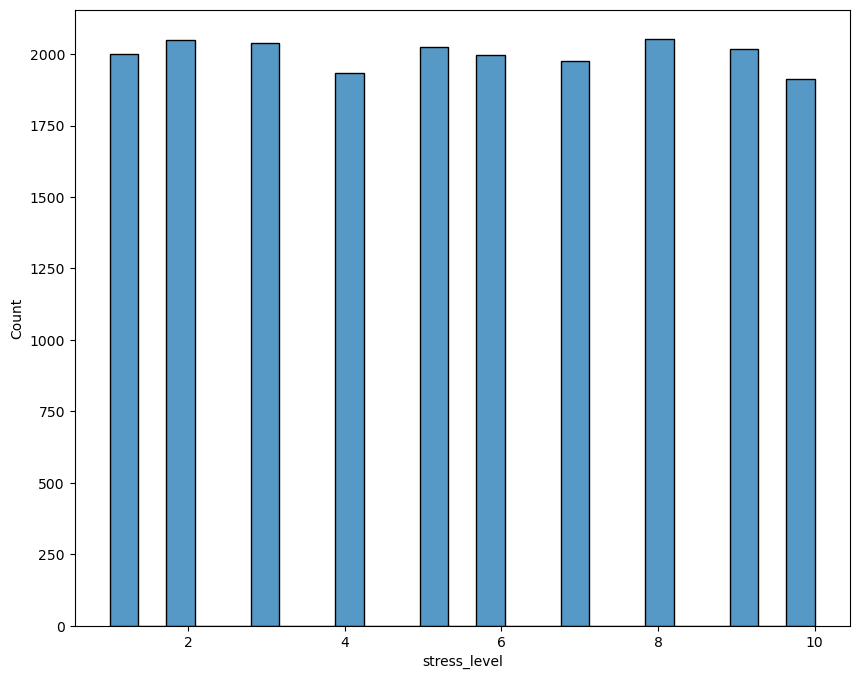

In [151]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x="stress_level")

<Axes: xlabel='focus_score', ylabel='Count'>

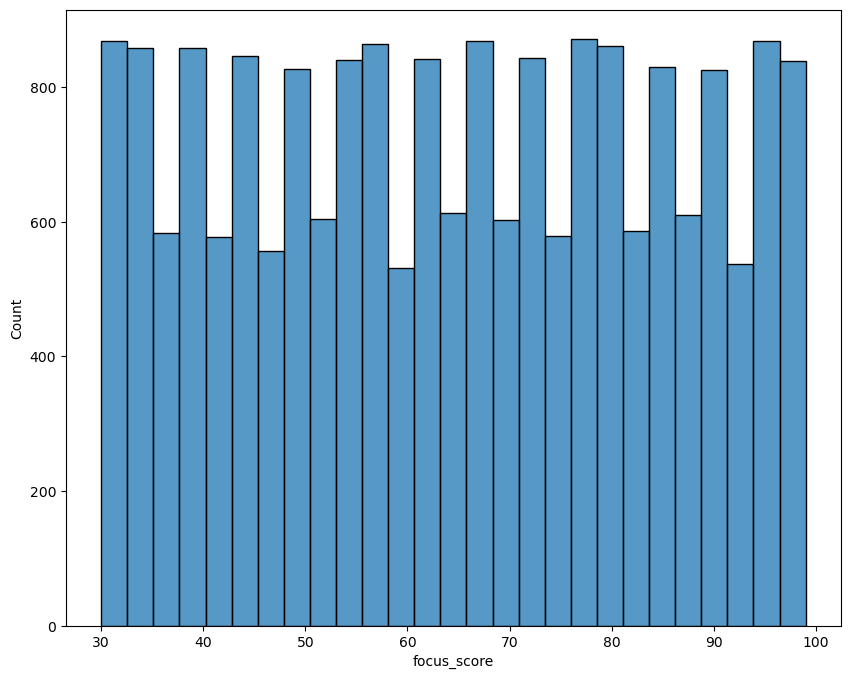

In [152]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x="focus_score")

In [ ]:
#preparing and training model

In [156]:
features = ["study_hours_per_day","sleep_hours","phone_usage_hours","attendance_percentage","stress_score","focus_score"]
X = dfml.drop("productivity_score", axis=1)
y = dfml["productivity_score"]


In [ ]:
#split data

In [157]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=.2, random_state=42)

In [ ]:
#scale features

In [159]:
scalar=StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)

In [ ]:
#train random forest

In [163]:
rf_reg = RandomForestRegressor(n_estimators=100,random_state=42)
rf_reg.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [167]:
y_predict = rf_reg.predict(X_test_scaled)

In [169]:
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 4.5682929102499985
R² Score: 0.9822653164689523


In [ ]:
#Make pipeline

In [173]:
features2 = ["study_hours_per_day","sleep_hours","phone_usage_hours",
            "attendance_percentage","stress_level","focus_score"]

In [175]:
X = dfml[features2]
y=dfml["productivity_score"]

In [178]:
pipeline = Pipeline([("scalar",StandardScaler()),("regressor",RandomForestRegressor(n_estimators=100,random_state=42))])

In [ ]:
#Train model

In [179]:
pipeline.fit(X_train,y_train)

,steps,"[('scalar', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [180]:
y_pred = pipeline.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))


MSE: 4.553386079684999
R^2: 0.9823231866466566


In [190]:
new_student = pd.DataFrame({
    "study_hours_per_day": [6],
    "sleep_hours": [9],
    "phone_usage_hours": [5],
    "attendance_percentage": [95],
    "stress_level": [2],  # numeric encoding of stress
    "focus_score": [100]})
predicted_productivity = pipeline.predict(new_student)
print("Predicted Productivity Score:", predicted_productivity[0])

Predicted Productivity Score: 77.07840000000007
